     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  2012-09-04       58       635  ...                  7             0   
1  2014-03-08       38        11  ...                  5             0   
2  2013-08-21       26       426  ...                  4             0   
3  2014-02-10       26        11  ...                  6             0   
4  2014-01-19       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

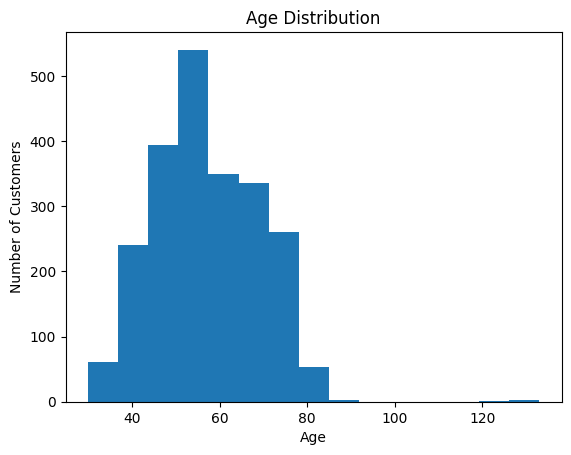

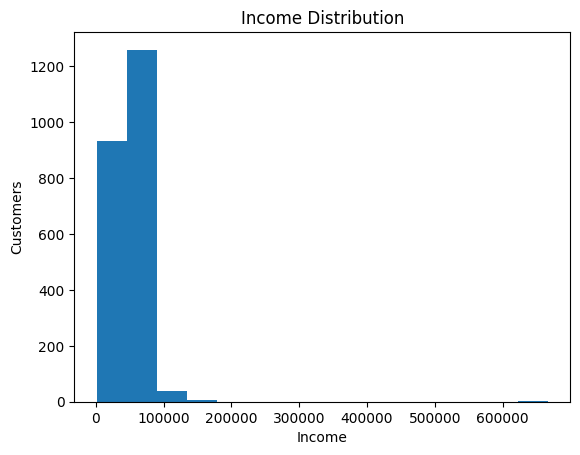

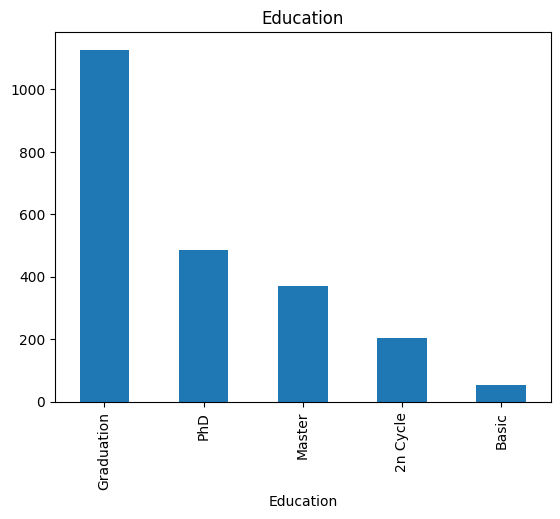

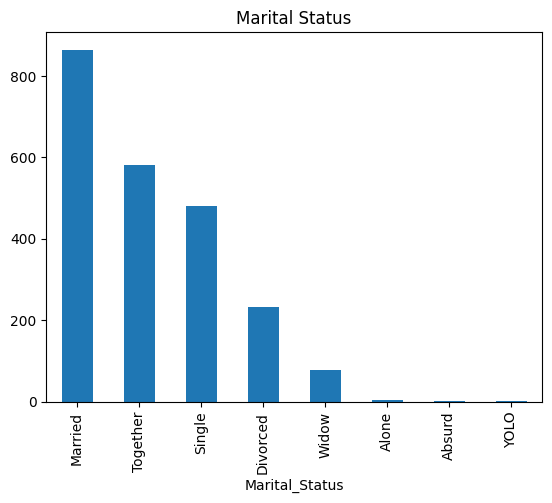

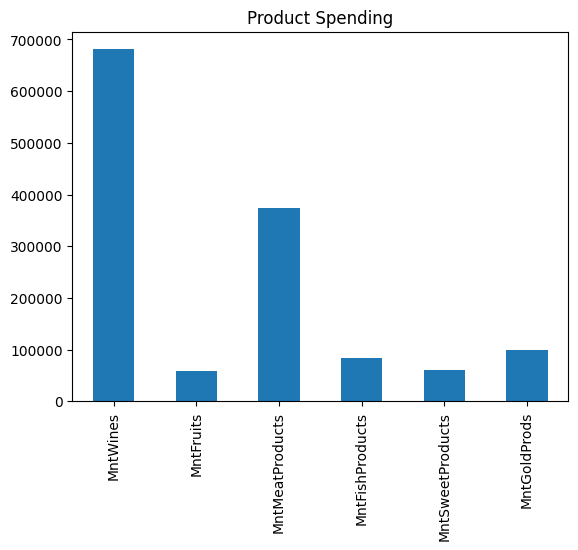

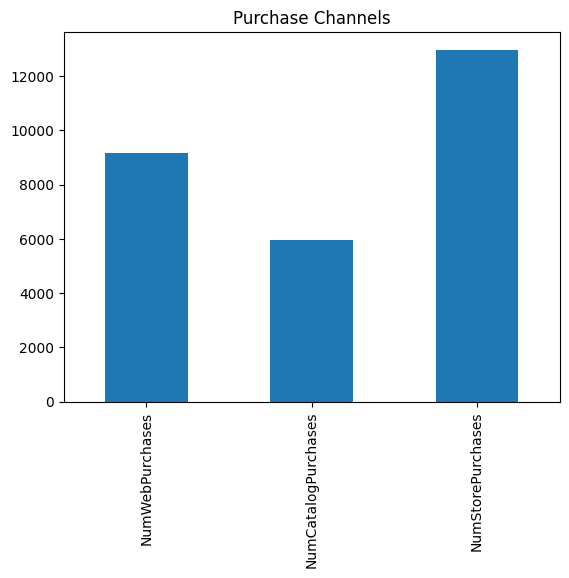

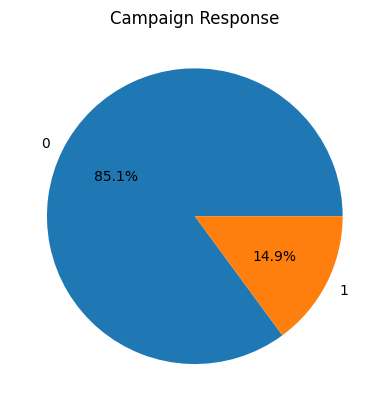

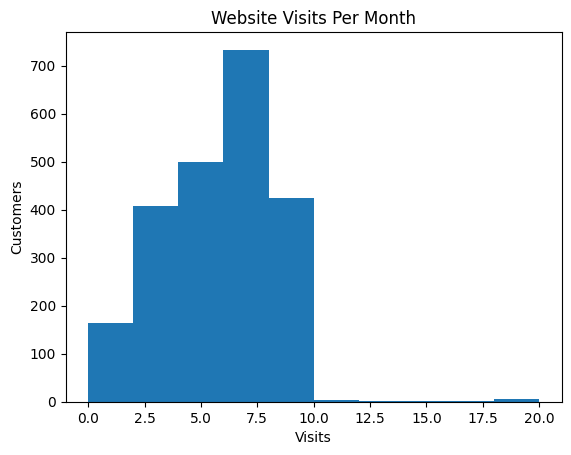

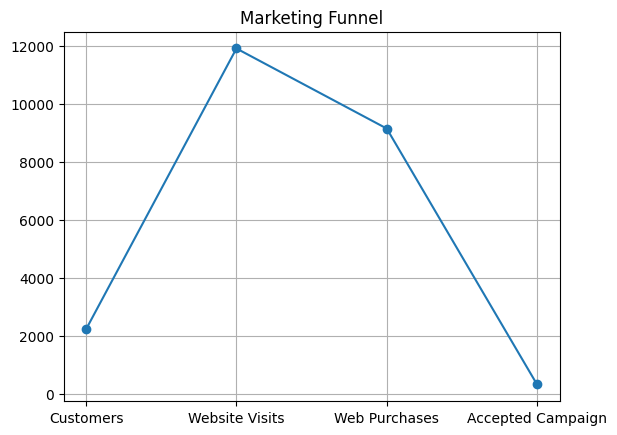

Average Age : 57.19
Average Income : 52237.98

Average Spending by Education
Education
2n Cycle      496.527094
Basic          81.796296
Graduation    619.898846
Master        611.781081
PhD           672.409465
Name: Total_Spent, dtype: float64

Average Spending by Marital Status
Marital_Status
Absurd      1192.500000
Alone        256.666667
Divorced     610.629310
Married      590.802083
Single       606.483333
Together     608.387931
Widow        738.818182
YOLO         424.000000
Name: Total_Spent, dtype: float64

Purchases by Channel
NumWebPurchases         9150
NumCatalogPurchases     5963
NumStorePurchases      12970
dtype: int64

Campaign Response
Response
0    1906
1     334
Name: count, dtype: int64

Top 5 Customers by Spending
        ID  Total_Spent
1572  5350         2525
1179  5735         2525
1492  1763         2524
987   4580         2486
1052  4475         2440

Business Recommendations
- Focus more on customers with higher income.
- Increase marketing on the channel 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the dataset
df = pd.read_excel("marketing_campaign.xlsx")

# Display first few rows
print(df.head())

# Check basic information
print(df.info())

# Check missing values
print(df.isnull().sum())

# Fill missing values in Income
df["Income"] = df["Income"].fillna(df["Income"].median())

# Remove duplicate rows
df = df.drop_duplicates()

# Convert date column
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"])

# Create Age column
df["Age"] = 2026 - df["Year_Birth"]

# Create Total Spending column
df["Total_Spent"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

# -----------------------------
# Graph 1 - Age Distribution
# -----------------------------
plt.hist(df["Age"], bins=15)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

# -----------------------------
# Graph 2 - Income Distribution
# -----------------------------
plt.hist(df["Income"], bins=15)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Customers")
plt.show()

# -----------------------------
# Graph 3 - Education
# -----------------------------
df["Education"].value_counts().plot(kind="bar")
plt.title("Education")
plt.show()

# -----------------------------
# Graph 4 - Marital Status
# -----------------------------
df["Marital_Status"].value_counts().plot(kind="bar")
plt.title("Marital Status")
plt.show()

# -----------------------------
# Graph 5 - Product Spending
# -----------------------------
products = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

df[products].sum().plot(kind="bar")
plt.title("Product Spending")
plt.show()

# -----------------------------
# Graph 6 - Purchase Channels
# -----------------------------
channels = ["NumWebPurchases","NumCatalogPurchases","NumStorePurchases"]

df[channels].sum().plot(kind="bar")
plt.title("Purchase Channels")
plt.show()

# -----------------------------
# Graph 7 - Campaign Response
# -----------------------------
df["Response"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Campaign Response")
plt.ylabel("")
plt.show()

# -----------------------------
# Graph 8 - Website Visits
# -----------------------------
plt.hist(df["NumWebVisitsMonth"], bins=10)
plt.title("Website Visits Per Month")
plt.xlabel("Visits")
plt.ylabel("Customers")
plt.show()

# -----------------------------
# Marketing Funnel
# -----------------------------
customers = len(df)
web_visits = df["NumWebVisitsMonth"].sum()
web_purchases = df["NumWebPurchases"].sum()
accepted = df["Response"].sum()

plt.plot(
    ["Customers","Website Visits","Web Purchases","Accepted Campaign"],
    [customers, web_visits, web_purchases, accepted],
    marker="o"
)
plt.title("Marketing Funnel")
plt.grid(True)
plt.show()

# -----------------------------
# Business Insights
# -----------------------------
print("Average Age :", round(df["Age"].mean(),2))
print("Average Income :", round(df["Income"].mean(),2))

print("\nAverage Spending by Education")
print(df.groupby("Education")["Total_Spent"].mean())

print("\nAverage Spending by Marital Status")
print(df.groupby("Marital_Status")["Total_Spent"].mean())

print("\nPurchases by Channel")
print(df[channels].sum())

print("\nCampaign Response")
print(df["Response"].value_counts())

print("\nTop 5 Customers by Spending")
print(df[["ID","Total_Spent"]].sort_values(by="Total_Spent", ascending=False).head())

print("\nBusiness Recommendations")
print("- Focus more on customers with higher income.")
print("- Increase marketing on the channel with the highest purchases.")
print("- Improve campaign response through better offers.")
print("- Retain high spending customers with loyalty programs.")
print("- Since cost and revenue are not available, ROI cannot be calculated directly.")